# Mobile price prediction

### 0. Project Overview
>This project aims to classify mobile phone price ranges based on various hardware specifications.  
>I will compare multiple machine learning algorithms to identify the most accurate predictor.

#### Methodology (Pipeline)
>**1. EDA** ➔ **2. Pre-processing** ➔ **3. Model Training** ➔ **4. Evaluation** ➔ **5. Optimization**

#### Candidate Models
>I will implement and benchmark the following classifiers:
>* **Decision Tree**
>* **Random Forest**
>* **KNN** (K-Nearest Neighbors)
>* **SVC** (Support Vector Classifier)

#### Goal
>Compare the performance (primarily **Accuracy**) of these models to determine the optimal solution for mobile price classification.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.metrics import classification_report, confusion_matrix , ConfusionMatrixDisplay


from sklearn import tree
from sklearn.decomposition import PCA, IncrementalPCA, FactorAnalysis #還沒用到







#交叉驗證 scores = cross_val_score(DTs, x_norm, y.ravel(), cv=5)  模型的泛化能力
# from sklearn.model_selection import KFold               # for cross validation
# import mpl_toolkit.mplot3d
from sklearn.model_selection import GridSearchCV
# import joblib #輸出pkl
# from sklearn.pipeline import Pipeline

### 1. EDA

In [2]:
train = pd.read_csv("train.csv")
train.T

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
battery_power,842.0,1021.0,563.0,615.0,1821.0,1859.0,1821.0,1954.0,1445.0,509.0,...,1617.0,1882.0,674.0,1467.0,858.0,794.0,1965.0,1911.0,1512.0,510.0
blue,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
clock_speed,2.2,0.5,0.5,2.5,1.2,0.5,1.7,0.5,0.5,0.6,...,2.4,2.0,2.9,0.5,2.2,0.5,2.6,0.9,0.9,2.0
dual_sim,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
fc,1.0,0.0,2.0,0.0,13.0,3.0,4.0,0.0,0.0,2.0,...,8.0,11.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,5.0
four_g,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
int_memory,7.0,53.0,41.0,10.0,44.0,22.0,10.0,24.0,53.0,9.0,...,36.0,44.0,21.0,18.0,50.0,2.0,39.0,36.0,46.0,45.0
m_dep,0.6,0.7,0.9,0.8,0.6,0.7,0.8,0.8,0.7,0.1,...,0.8,0.8,0.2,0.6,0.1,0.8,0.2,0.7,0.1,0.9
mobile_wt,188.0,136.0,145.0,131.0,141.0,164.0,139.0,187.0,174.0,93.0,...,85.0,113.0,198.0,122.0,84.0,106.0,187.0,108.0,145.0,168.0
n_cores,2.0,3.0,5.0,6.0,2.0,1.0,8.0,4.0,7.0,5.0,...,1.0,8.0,3.0,5.0,1.0,6.0,4.0,8.0,5.0,6.0


In [3]:
train.shape

(2000, 21)

In [4]:
print(f"Duplicated : {train.duplicated().sum()}\n")
print(f"Isnull : \n{train.isnull().sum()}\n")
print(f"Isna : \n{train.isna().sum()}")

Duplicated : 0

Isnull : 
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Isna : 
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


#### **Mobile Specification Column Definitions**

| Column | NameSimple |
| :--- | :--- |
| **battery_power** | battery capacity |
| **blue** | bluetooth |
| **clock_speed** | processor speed |
| **dual_sim** | dual SIM card |
| **fc** | front camera |
| **four_g** | 4G network |
| **int_memory** | internal storage |
| **m_dep** | mobile depth |
| **mobile_wt** | weight |
| **n_cores** | number of cores |
| **pc** | primary camera |
| **px_height** | pixel height |
| **px_width** | pixel width |
| **ram** | ram |
| **sc_h** | screen height |
| **sc_w** | screen width |
| **talk_time** | talk time |
| **three_g** | 3G network |
| **touch_screen** | touch screen |
| **wifi** | wi-fi |
| **price_range** | price target |

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [6]:
train.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


>Strange values in `px_height` and `sc_w`.

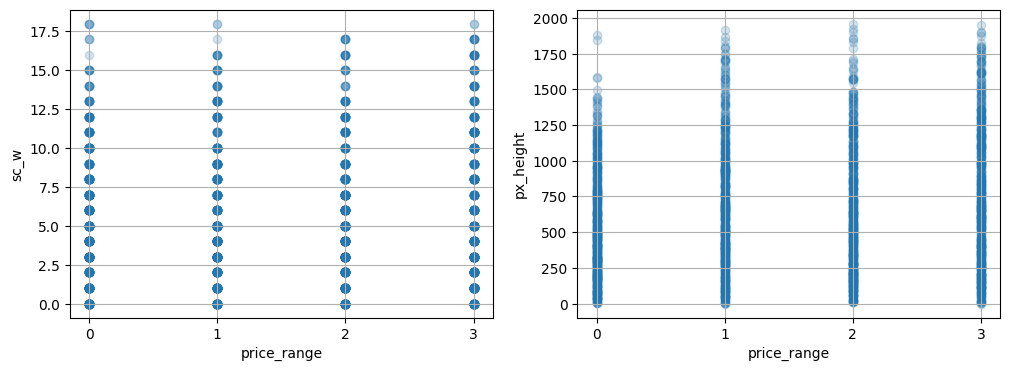

In [7]:
# Strange values checked by plot
strange_val = ["sc_w", "px_height"]
price_range_category = tuple(set(train["price_range"]))

plt.figure(figsize = [12, 4])
for i in range(len(strange_val)):
    plt.subplot(1, 2, i+1)
    plt.scatter(train["price_range"], train[strange_val[i]], alpha = .2)
    plt.xlabel("price_range")
    plt.xticks(price_range_category)
    plt.ylabel(strange_val[i])
    plt.grid()
plt.show()

In [8]:
train_check = train[train ["px_height"] <= 100]
print(f"There are {len(train_check)} records with 'px_height'.")
train_check

There are 151 records with 'px_height'.


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
32,1319,1,0.9,0,3,1,41,0.9,107,1,...,85,1152,2227,18,5,3,1,1,1,1
47,1054,1,1.8,1,3,1,40,0.8,196,7,...,27,774,2296,16,12,12,1,0,1,1
73,1038,0,1.2,0,3,0,43,0.7,141,1,...,4,638,3709,11,0,12,1,1,1,3
86,1496,1,2.0,1,4,0,42,0.5,182,5,...,96,741,854,16,0,7,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1948,748,0,1.4,0,0,0,25,1.0,110,7,...,88,709,1974,17,5,13,0,1,1,1
1954,686,1,2.7,1,0,0,36,0.1,194,4,...,64,745,1503,10,0,13,0,0,0,0
1963,1906,1,1.9,1,3,0,55,0.2,113,3,...,3,629,1871,13,5,4,1,0,1,1
1972,1191,0,0.8,0,6,1,46,0.8,89,6,...,42,807,824,19,18,7,1,0,0,0


In [9]:
train_check = train[train["sc_w"] <= 1]
print(f"There are {len(train_check)} records with 'sc_w'.")
train_check

There are 390 records with 'sc_w'.


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1
8,1445,1,0.5,0,0,0,53,0.7,174,7,...,386,836,1099,17,1,20,1,0,0,0
12,1815,0,2.8,0,2,0,33,0.6,159,4,...,607,748,1482,18,0,2,1,0,0,1
13,803,1,2.1,0,7,0,17,1.0,198,4,...,344,1440,2680,7,1,4,1,0,1,2
19,682,1,0.5,0,4,0,19,1.0,121,4,...,902,1064,2337,11,1,18,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1958,1976,1,2.6,1,6,0,45,1.0,136,4,...,652,1933,2470,11,1,3,0,0,0,3
1965,659,0,1.4,1,2,1,3,0.1,85,8,...,190,657,967,10,1,14,1,0,1,0
1981,1454,0,2.6,0,8,0,6,0.4,199,3,...,698,1018,1300,10,0,2,0,0,1,1
1982,1784,0,1.6,0,4,0,41,0.4,164,6,...,610,1437,2313,14,1,11,0,1,0,2


<Axes: >

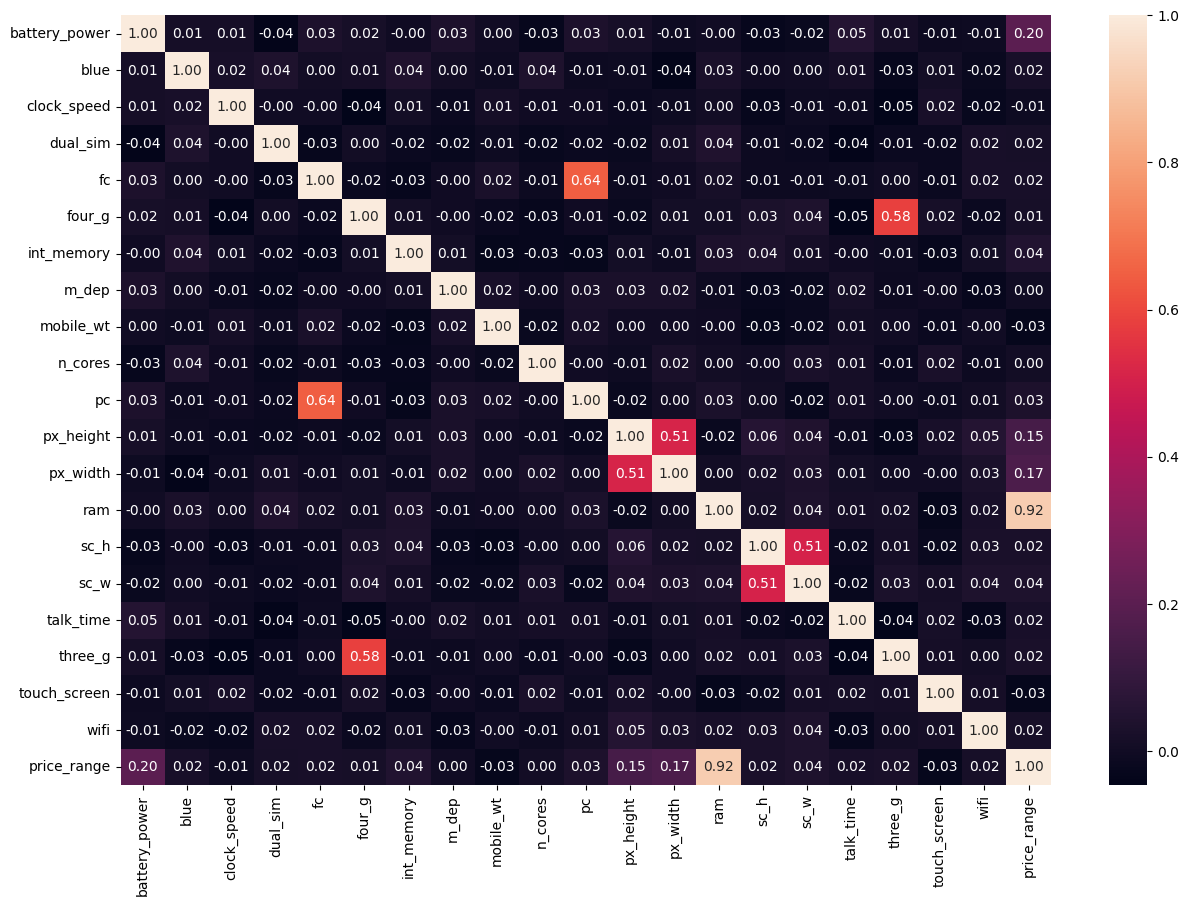

In [10]:
plt.figure(figsize=(15,10))
sns.heatmap(train.corr(), annot = True, fmt=".2f")

>Found some weird zero values in `px_height` and `sc_w`, looks like typos or missing data.  
>Also, since height and width for both pixels and screen are super correlated,  
>I'm **dropping these 4 columns** to keep the model clean.

<Axes: >

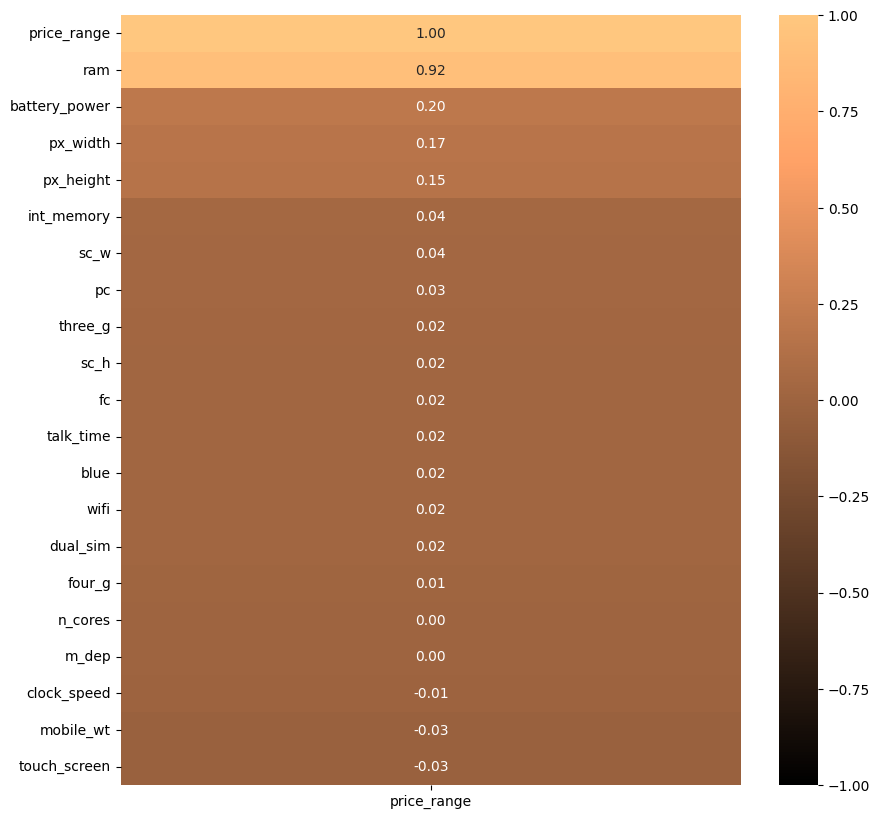

In [11]:
plt.figure(figsize=(10,10))
price_range = train.corr()[["price_range"]].sort_values(by = "price_range", ascending = False)
sns.heatmap(price_range, vmin = -1, vmax = 1, cmap = "copper", annot = True, fmt=".2f")

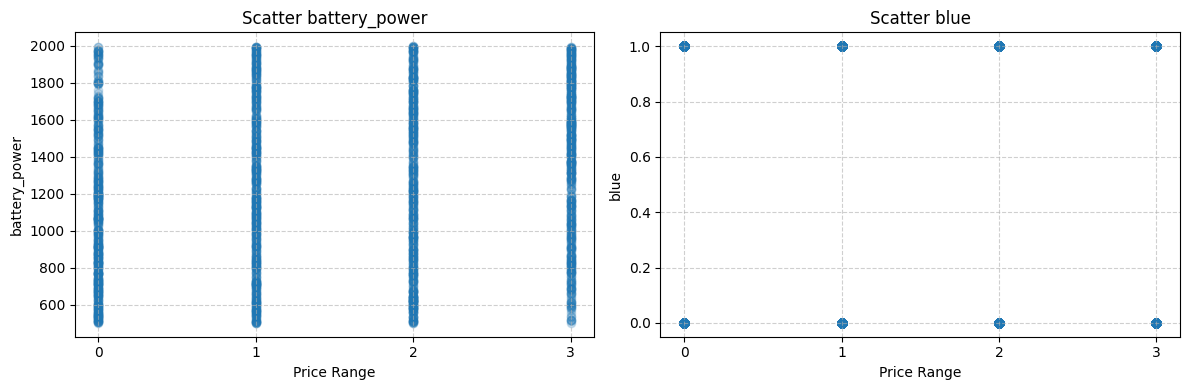

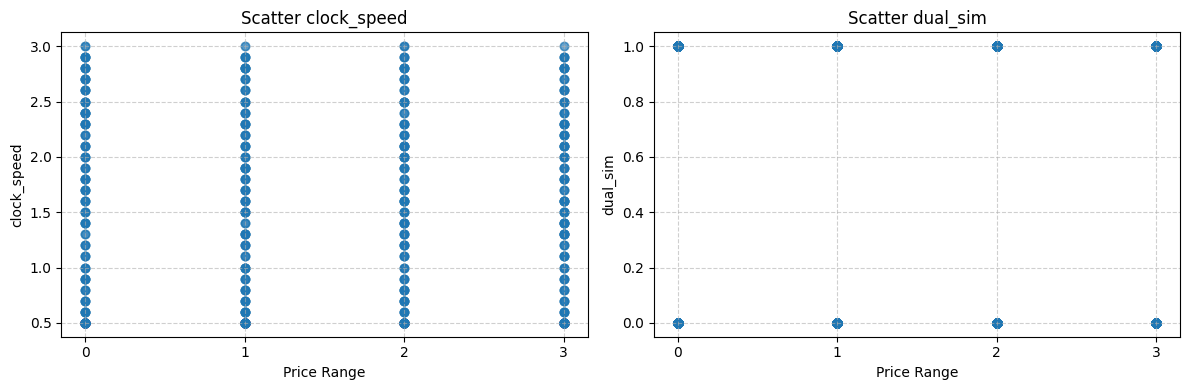

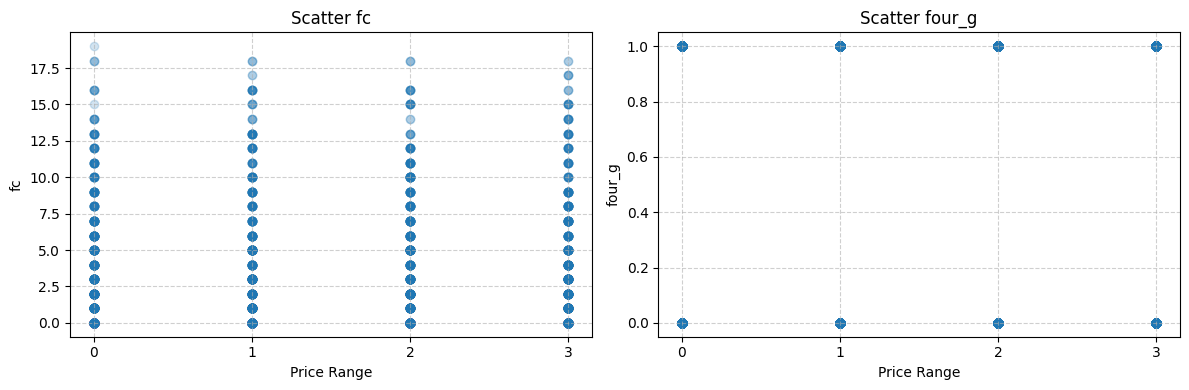

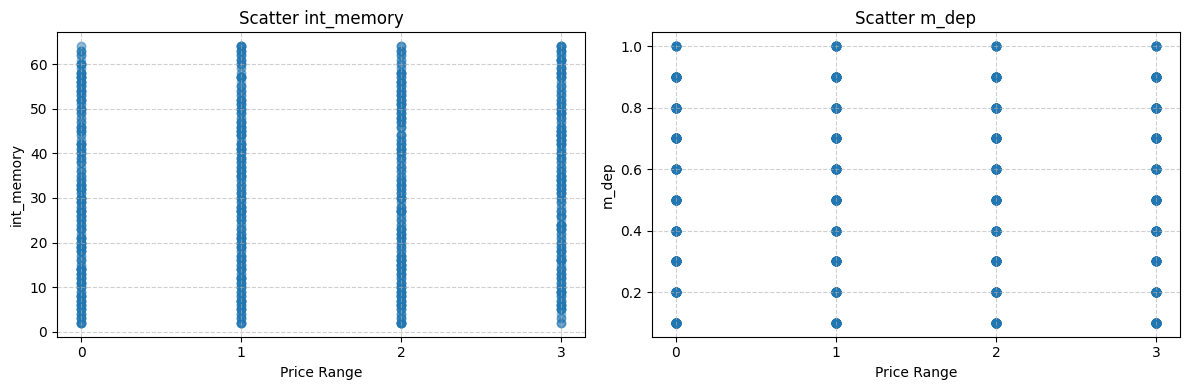

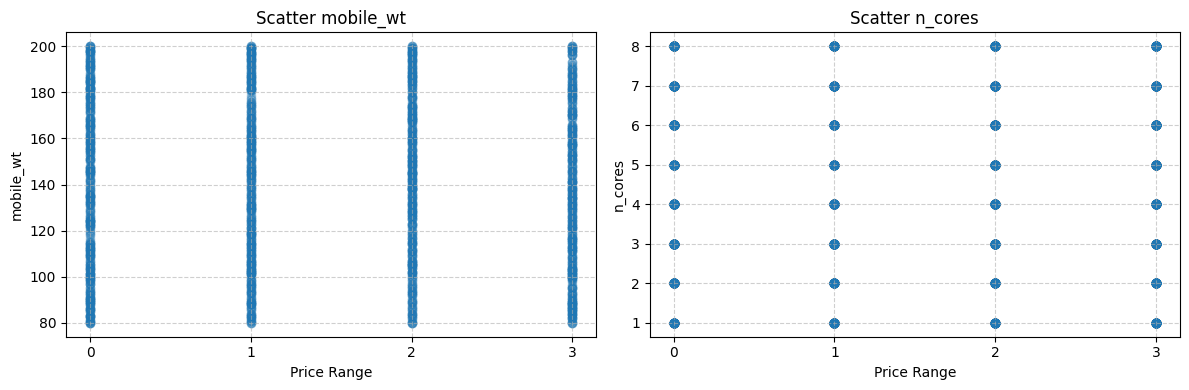

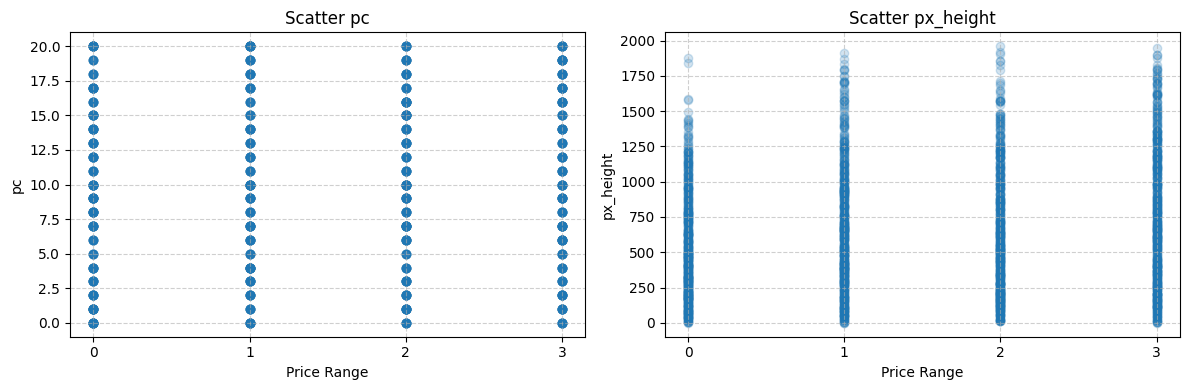

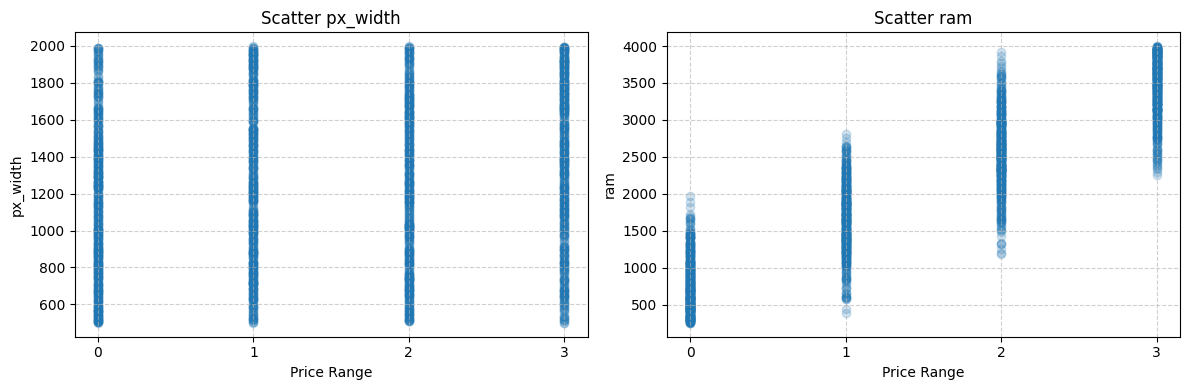

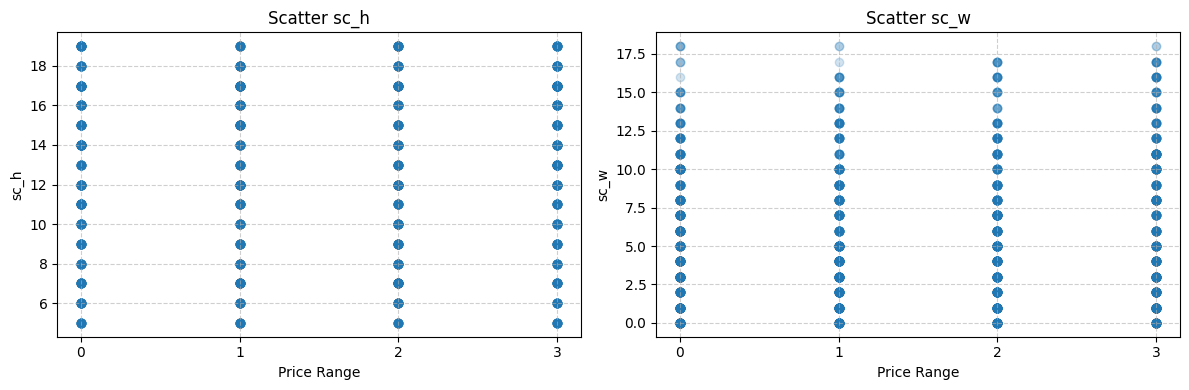

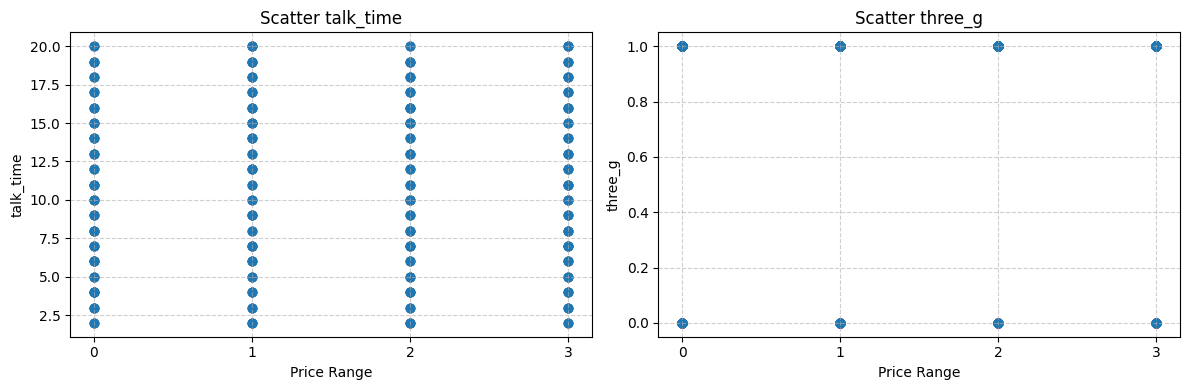

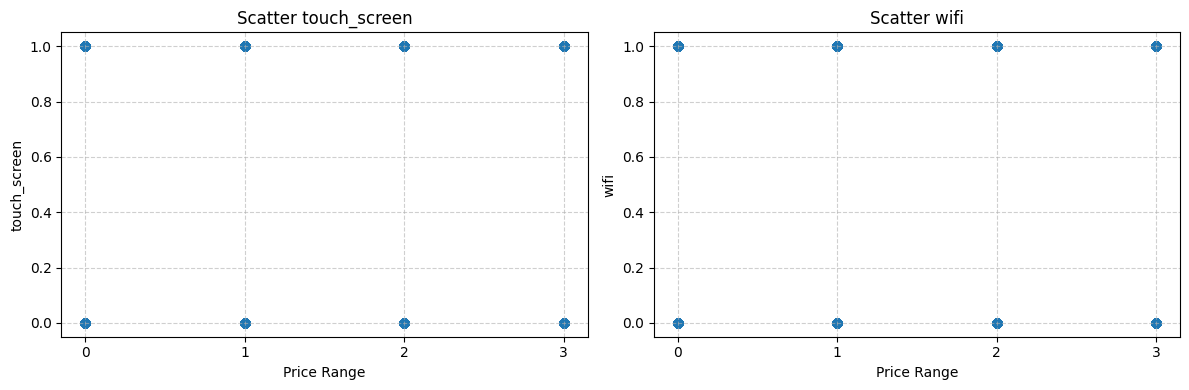

In [12]:
scatter_cols = train.drop("price_range", axis = 1).keys()

def plot_scatter(data, col_name, ax):
    ax.scatter(data["price_range"], data[col_name], alpha = .2)
    ax.set_title(f"Scatter {col_name}")
    ax.set_ylabel(col_name)
    ax.set_xlabel("Price Range")
    ax.set_xticks(price_range_category)
    ax.grid(True, linestyle = "--", alpha = .6)

for i in range(0, len(scatter_cols), 2):
    fig, axes = plt.subplots(1, 2, figsize = [12, 4])

    plot_scatter(train, scatter_cols[i], axes[0])
    if i+1 < len(scatter_cols):
        plot_scatter(train, scatter_cols[i+1], axes[1])
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

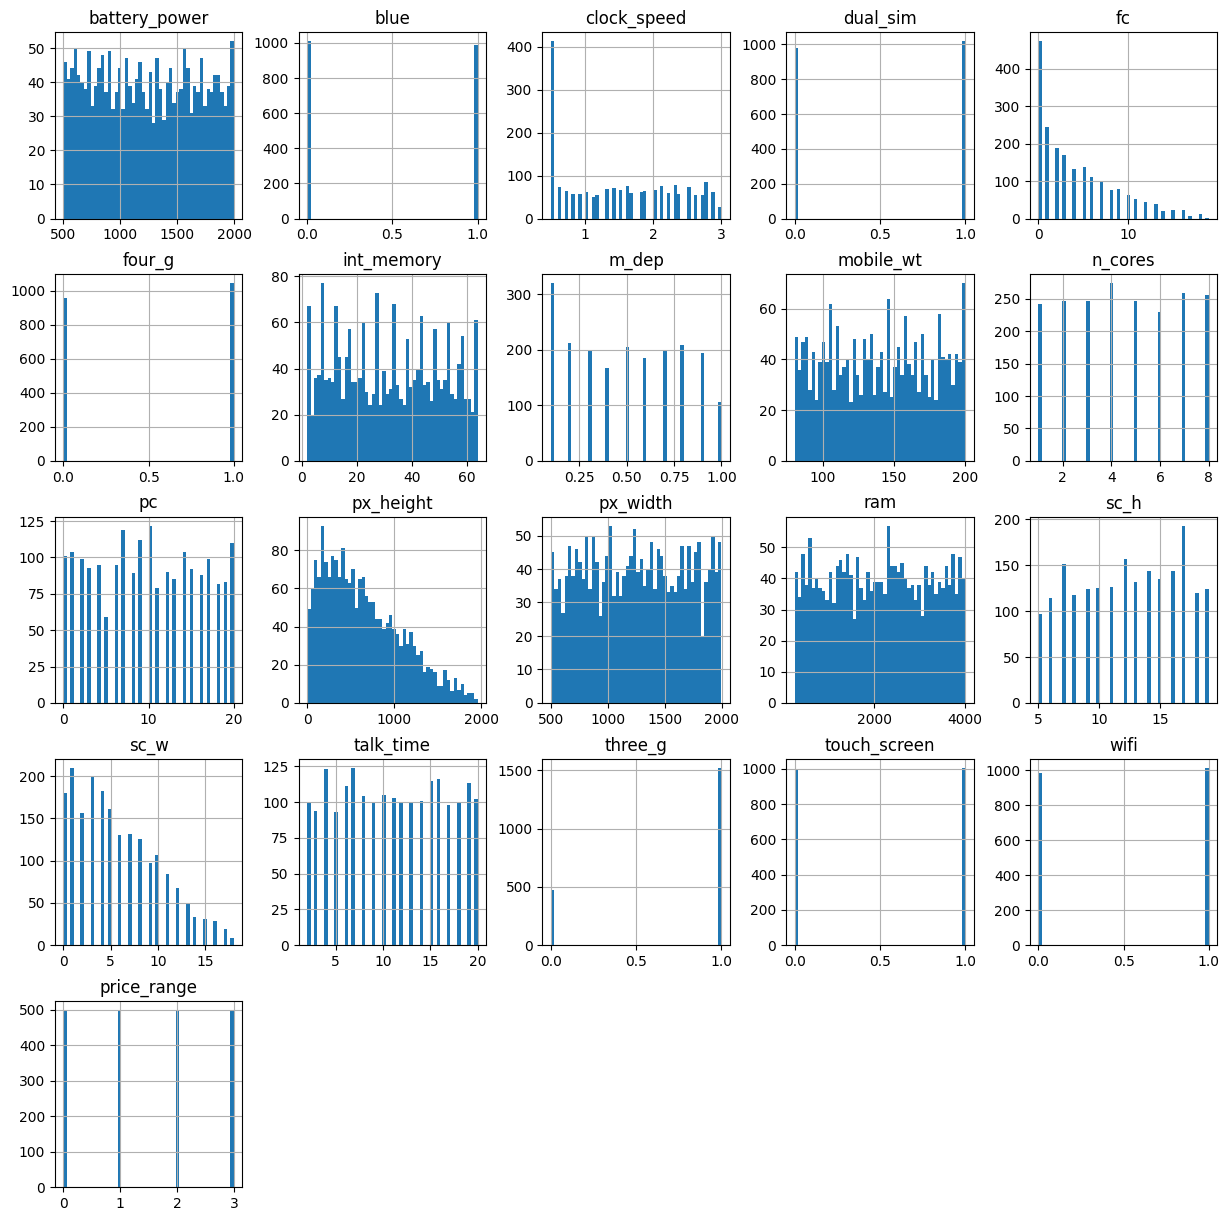

In [13]:
train.hist(bins = 50,figsize = (15, 15))
plt.show()

>Some are uniform, some are Bernoulli(0, 1), and others are skewed (either positively like Gamma, or negatively).  
>Let’s dive into the finer details.

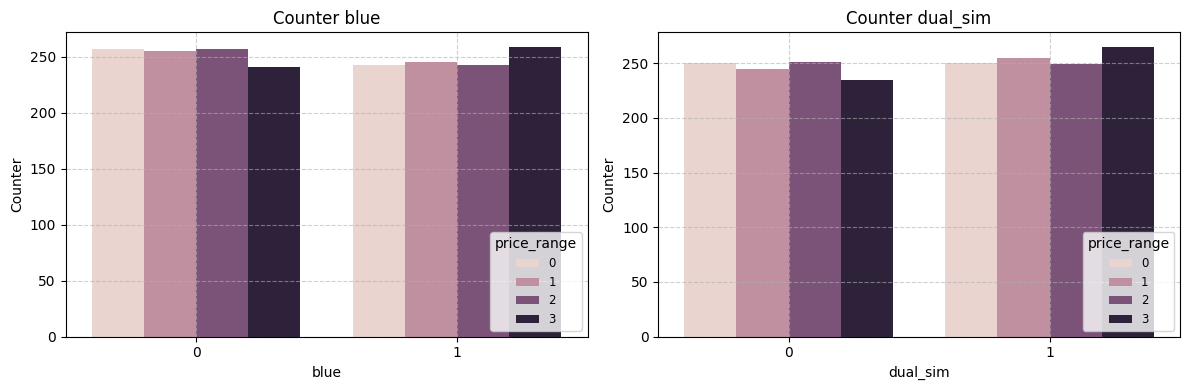

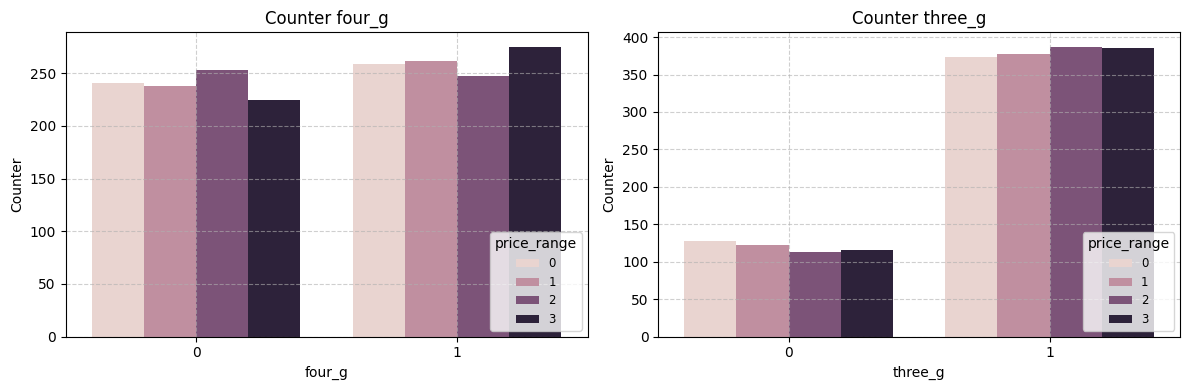

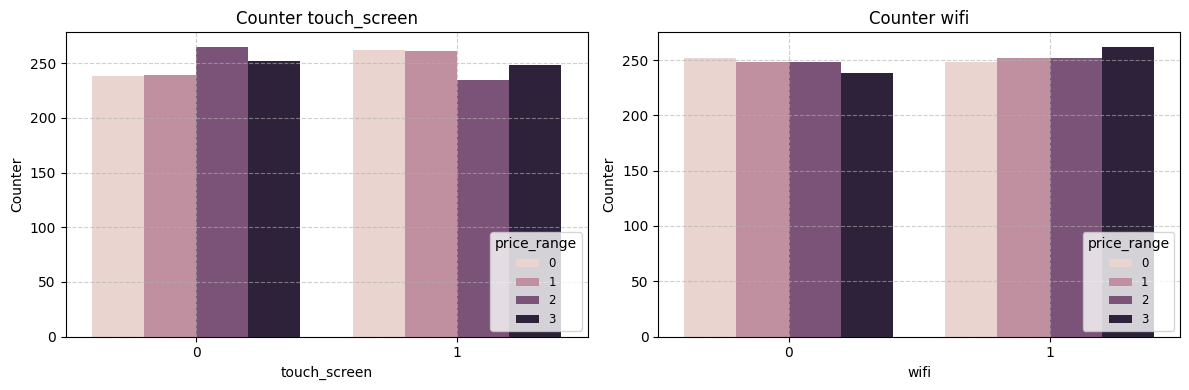

In [14]:
binary_cols = ["blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi"]
counter_cols = train[binary_cols].keys()

def plot_counter(data, col_name, ax):
    sns.countplot(data, x = col_name, hue = "price_range", ax = ax)
    ax.set_title(f"Counter {col_name}")
    ax.set_ylabel("Counter")
    ax.set_xlabel(col_name)
    ax.grid(True, linestyle = "--", alpha = .6)
    ax.legend(title = "price_range", loc = "lower right", fontsize = "small")

for i in range(0, len(counter_cols), 2):
    fig, axes = plt.subplots(1, 2, figsize = [12, 4])

    plot_counter(train, counter_cols[i], axes[0])
    if i+1 < len(counter_cols):
        plot_counter(train, counter_cols[i+1], axes[1])
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

>These six features are uniformly distributed regardless of being *True* or *False*, suggesting a **low impact on `price_range`**.  
>This observation aligns perfectly with the results from *heatmap*.  
>and more..

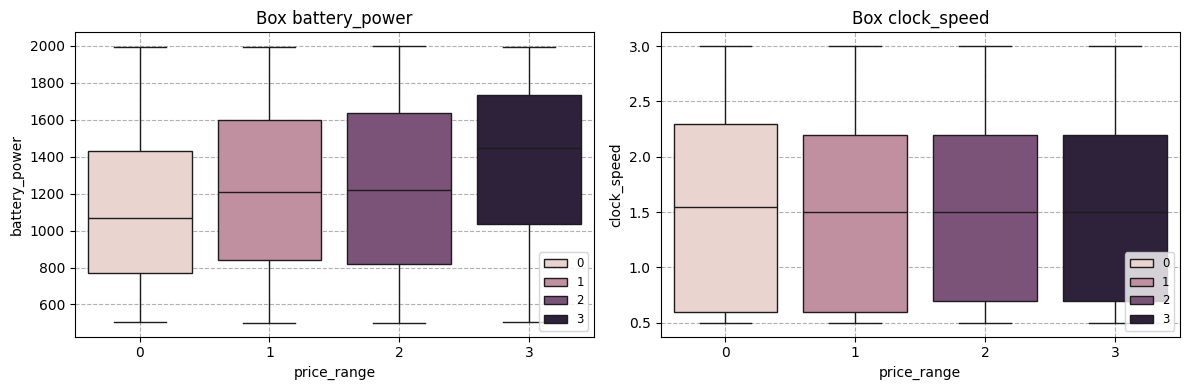

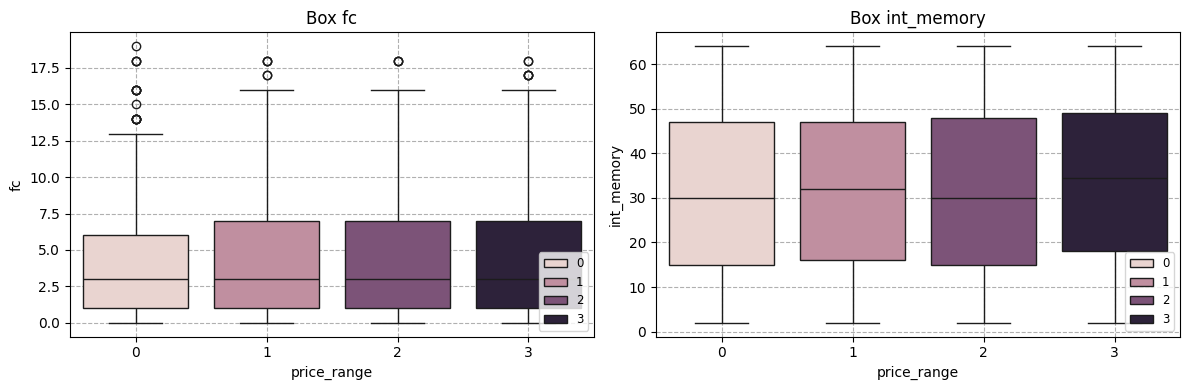

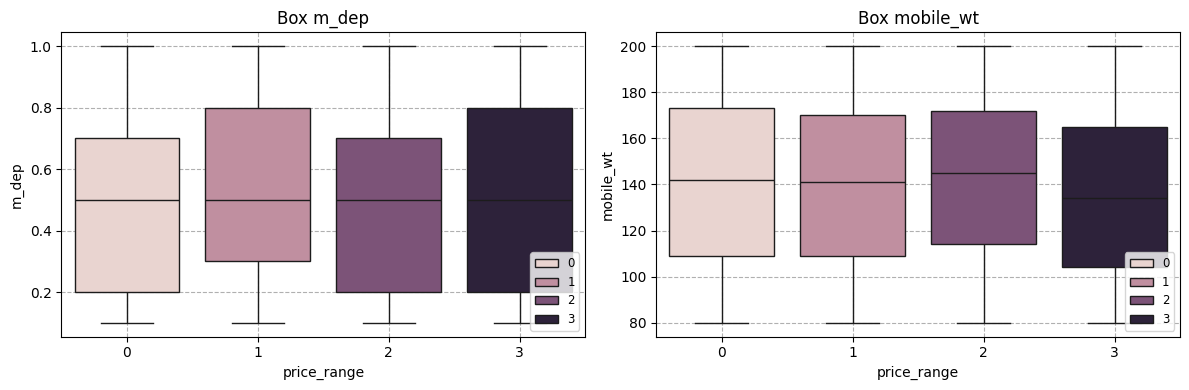

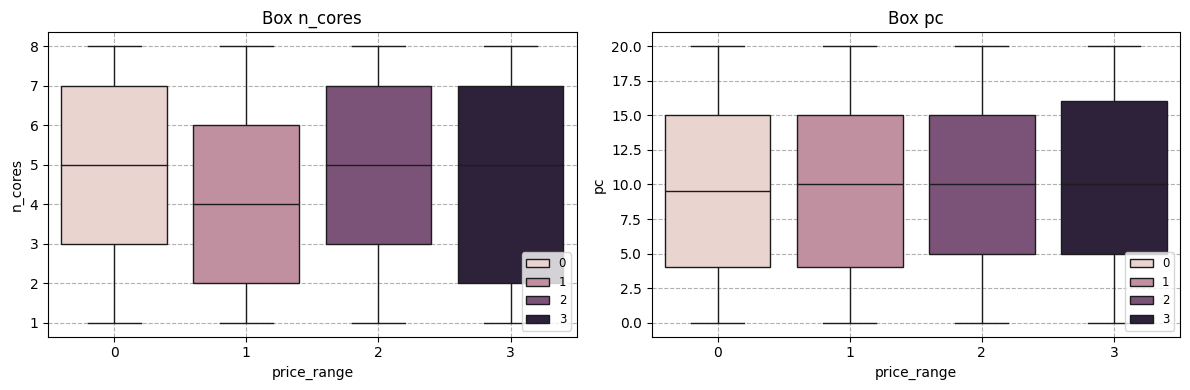

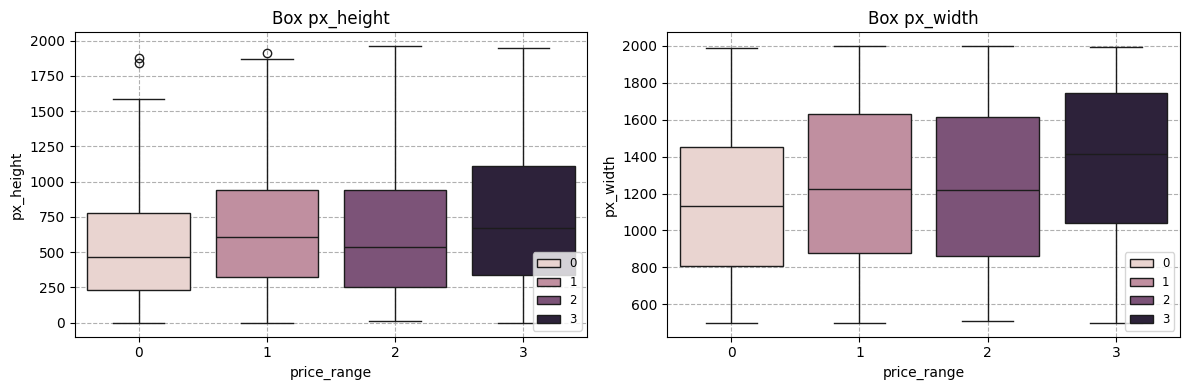

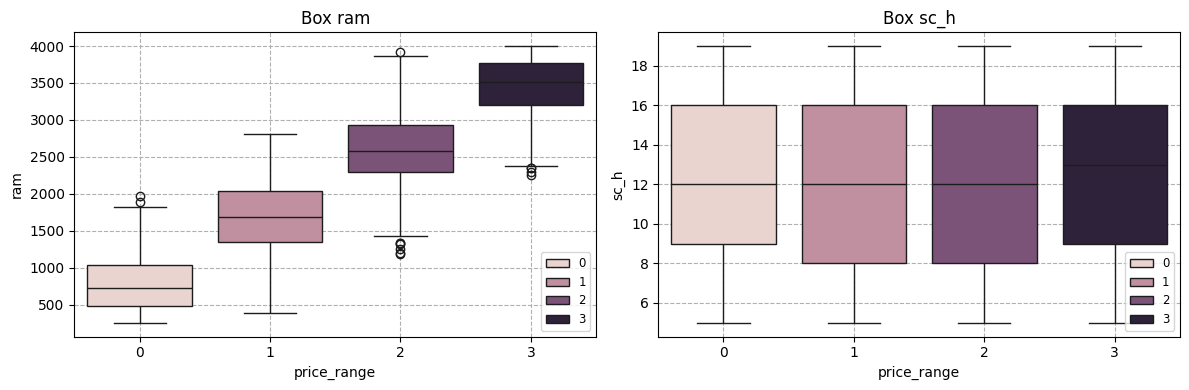

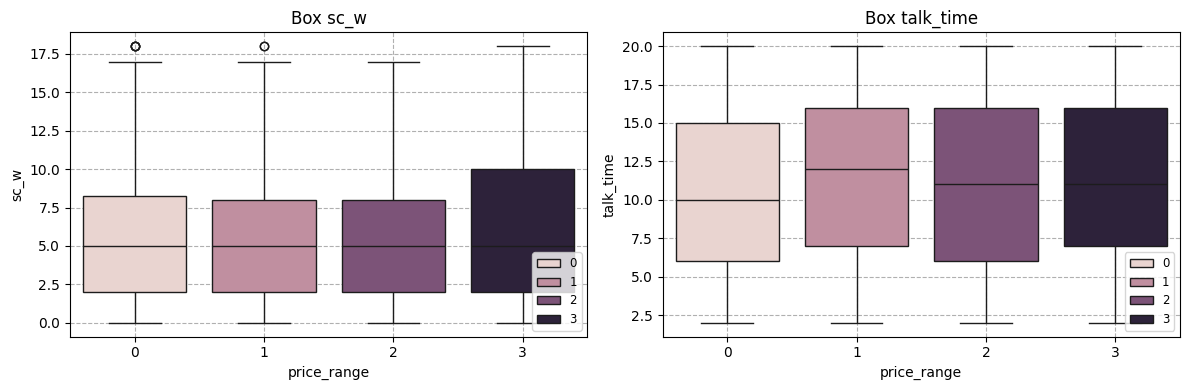

In [15]:
non_binary_cols = train.drop([*binary_cols, "price_range"], axis = 1).keys()

def plot_box(data, col_name, ax):
    sns.boxplot(data = train, x = "price_range", y = col_name, hue = "price_range", ax = ax)
    ax.set_title(f"Box {col_name}")
    ax.set_ylabel(col_name)
    ax.set_xlabel("price_range")
    ax.grid(True, linestyle = "--")
    ax.legend(loc = "lower right", fontsize = "small")

for i in range(0, len(non_binary_cols), 2):
    fig, axes = plt.subplots(1, 2, figsize = [12, 4])

    plot_box(train, non_binary_cols[i], axes[0])
    if i+1 < len(non_binary_cols):
        plot_box(train, non_binary_cols[i+1], axes[1])
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

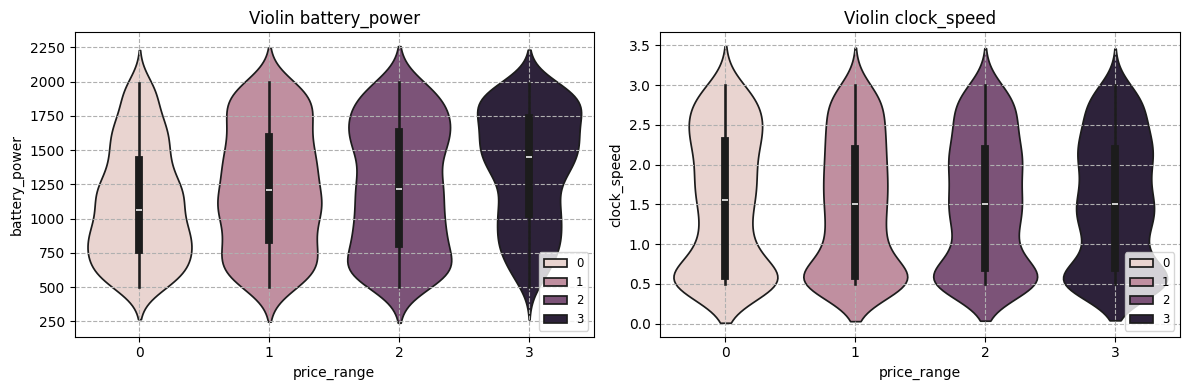

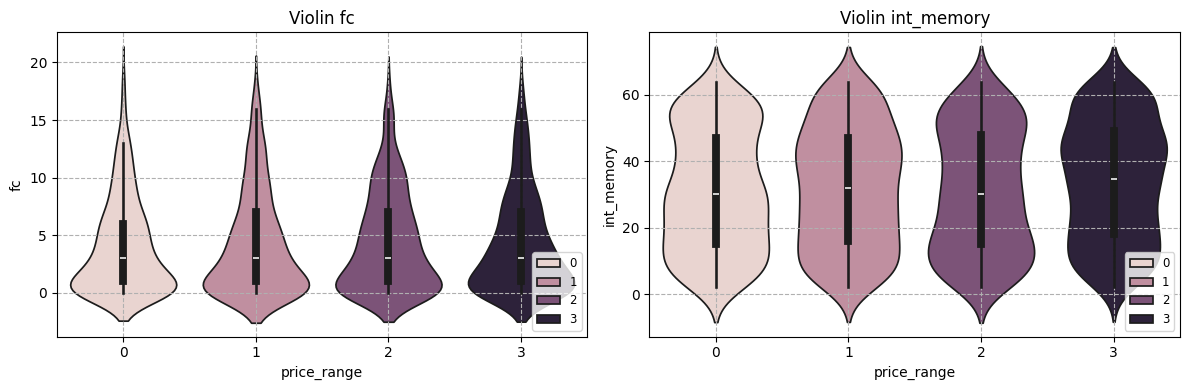

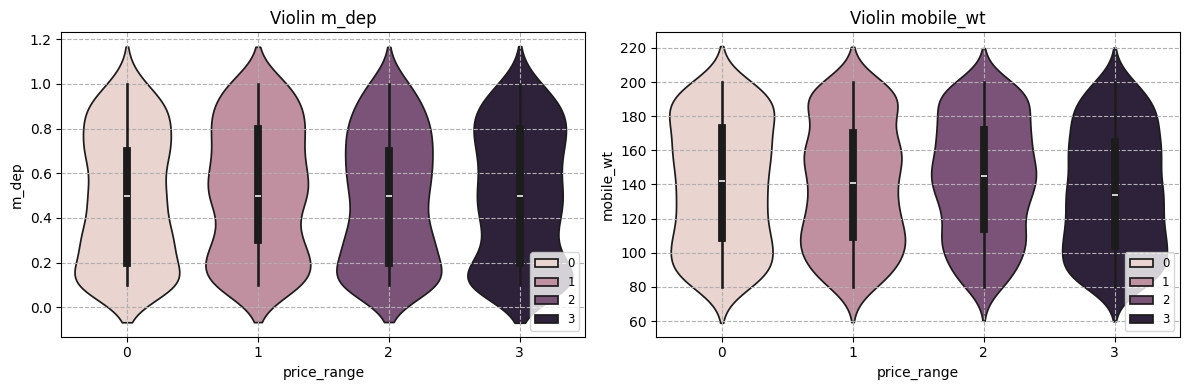

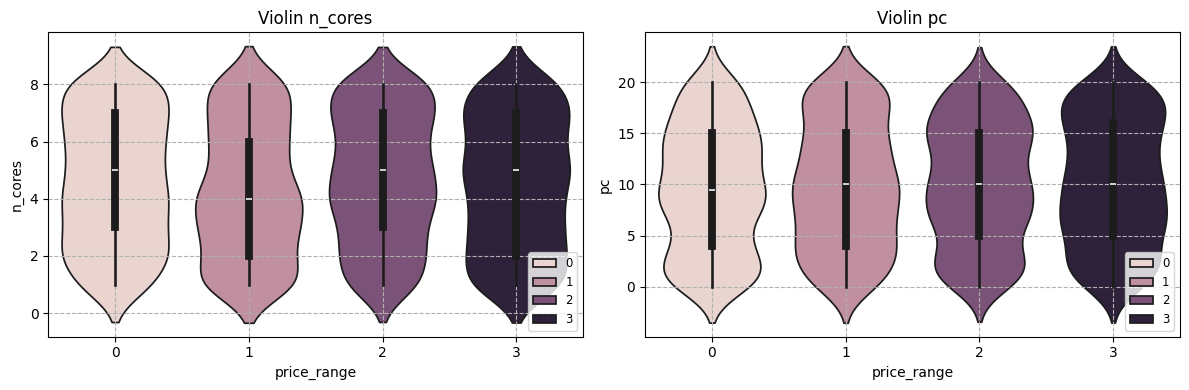

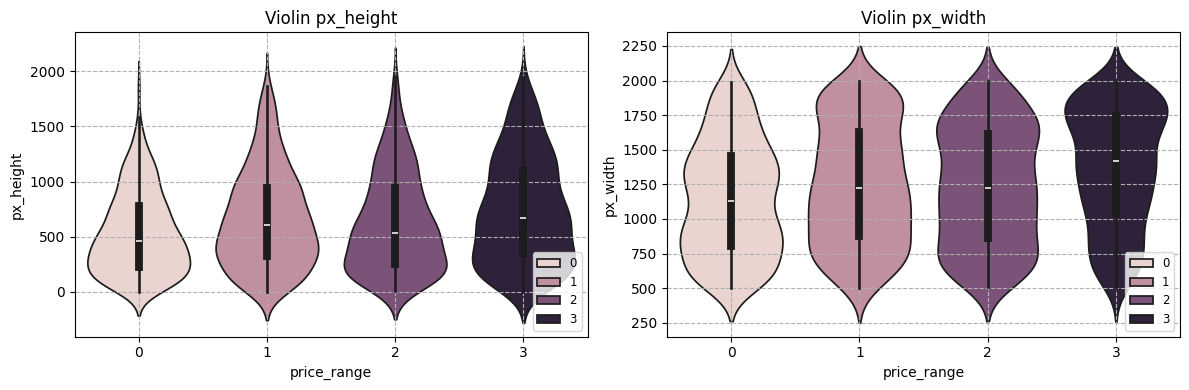

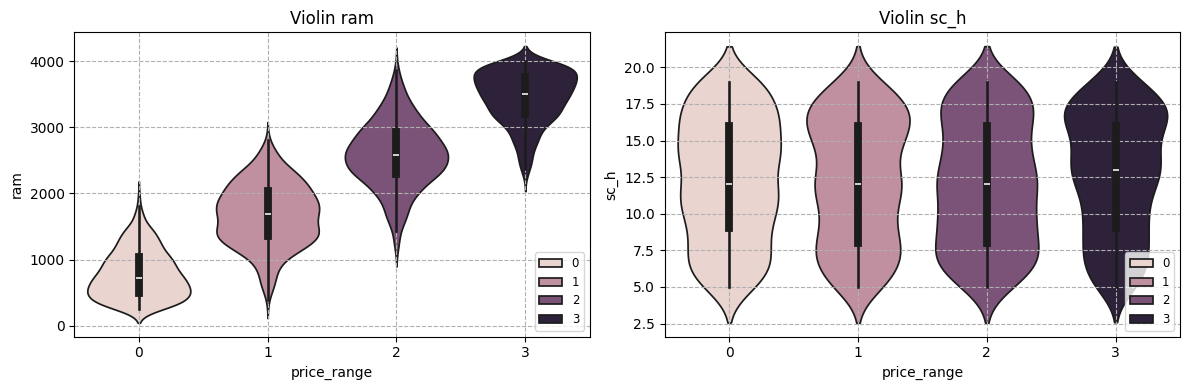

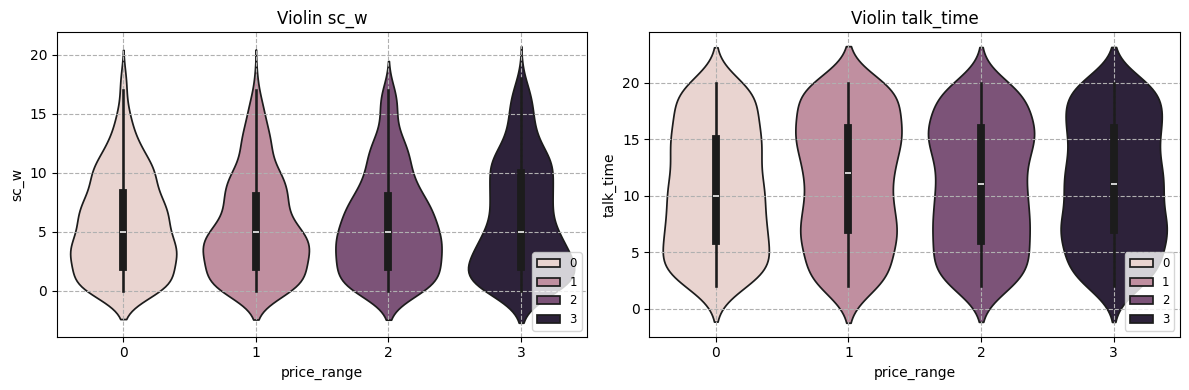

In [16]:
def plot_violin(data, col_name, ax):
    sns.violinplot(data = train, x = "price_range", y = col_name, hue = "price_range", ax = ax)
    ax.set_title(f"Violin {col_name}")
    ax.set_ylabel(col_name)
    ax.set_xlabel("price_range")
    ax.grid(True, linestyle = "--")
    ax.legend(loc = "lower right", fontsize = "small")

for i in range(0, len(non_binary_cols), 2):
    fig, axes = plt.subplots(1, 2, figsize = [12, 4])

    plot_violin(train, non_binary_cols[i], axes[0])
    if i+1 < len(non_binary_cols):
        plot_violin(train, non_binary_cols[i+1], axes[1])
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

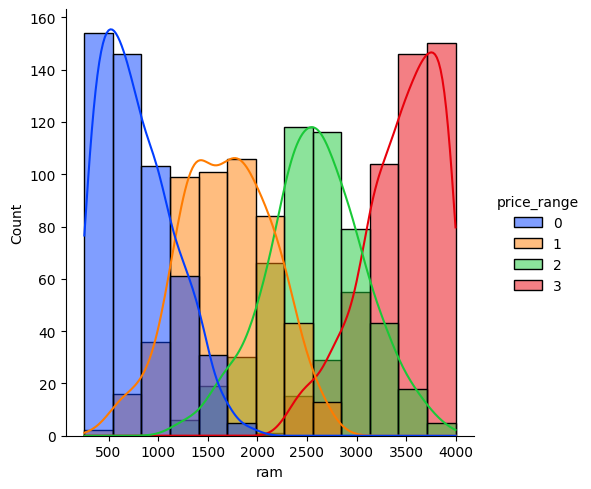

In [17]:
sns.displot(data = train, x = "ram", hue = "price_range", kind = "hist", kde = True, palette = "bright")
plt.show()

>Based on the EDA, RAM is the primary driver of price_range.  
>I will conduct six comparative experiments to systematically evaluate model performance and feature influence:  
>* **Baseline Train :** Using the full feature set.  
>* **"Only RAM" Ablation Study :** Evaluating the strongest individual predictor.  
>* **"No RAM" Ablation Study:** Assessing the model without the dominant feature.  
>* **Feature Selection (SelectKBest) :** Statistical filtering of key variables.  
>* **Dimensionality Reduction (PCA) :** Testing information compression.  
>* **Hyperparameter Optimization (GridSearchCV) :** Fine-tuning for peak performance.  
>
>  *Notes on Experimental Design* 
>1. **Noise Reduction & Feature Selection**  
>   The dataset consists of 20 features. Some may contain noise or provide negligible contributions.  
>   Through SelectKBest and Manual Feature Engineering, we will verify their impact on test accuracy to ensure the model focuses on the most informative variables.
>3. **Managing Feature Redundancy**  
>   Significant multicollinearity exists (e.g., pc & fc, three_g & four_g).  
>   We aim to explore whether selecting representative features or using PCA can achieve better generalization compared to the full feature set.
>5. **Ablation Study & Robustness**  
>   To quantify the influence of RAM, we have designed a symmetrical ablation study:  
> >* Full Model: The baseline performance.  
> >* Only RAM: Measuring the predictive power of the core driver.  
> >* No RAM: Observing how remaining variables (Battery, Pixels, etc.) perform without the "RAM factor" to test model robustness.

### 2. Pre-process

In [18]:
#Use it with random_state
RANDOM_SEED = 0

# player 1 : all feature
X_all = train.drop(["price_range"], axis = 1)
print(f"X_all shape : {X_all.shape}")

# player 2 : only ram feature
X_only_ram = train[["ram"]]
print(f"X_only_ram shape : {X_only_ram.shape}")

# player 3 : other than ram feature
X_no_ram = train.drop(["price_range", "ram"], axis = 1)
print(f"X_no_ram shape : {X_only_ram.shape}")

# player 4 : ram + bettery_power
X_r_b = train[["ram", "battery_power"]]
print(f"X_r_b shape : {X_r_b.shape}")

# player 5 : default dropped features
X_reduce4 = train.drop(["price_range", "pc", "fc", "three_g", "four_g"], axis = 1)
print(f"X_reduce4 shape : {X_reduce4.shape}")

y = train["price_range"]

X_all shape : (2000, 20)
X_only_ram shape : (2000, 1)
X_no_ram shape : (2000, 1)
X_r_b shape : (2000, 2)
X_reduce4 shape : (2000, 16)


In [19]:
# Use MinMaxScaler() to prevent chi2 from being biased by feature scales
for i in range(1,6):
    scaler = MinMaxScaler()
    selector = SelectKBest(chi2, k = i)
    X_scaler = pd.DataFrame(scaler.fit_transform(X_all), columns = X_all.columns)
    selector.fit_transform(X_scaler, y)
    selected_features = selector.get_feature_names_out()
    print(f"Chi2 selected features (k={i}) : {selected_features}")

for i in range(1,6):
    selector = SelectKBest(f_classif, k = i)
    selector.fit_transform(X_all, y)
    selected_features = selector.get_feature_names_out()
    print(f"Classif selected features (k={i}) : {selected_features}")

Chi2 selected features (k=1) : ['ram']
Chi2 selected features (k=2) : ['battery_power' 'ram']
Chi2 selected features (k=3) : ['battery_power' 'px_width' 'ram']
Chi2 selected features (k=4) : ['battery_power' 'px_height' 'px_width' 'ram']
Chi2 selected features (k=5) : ['battery_power' 'px_height' 'px_width' 'ram' 'touch_screen']
Classif selected features (k=1) : ['ram']
Classif selected features (k=2) : ['battery_power' 'ram']
Classif selected features (k=3) : ['battery_power' 'px_width' 'ram']
Classif selected features (k=4) : ['battery_power' 'px_height' 'px_width' 'ram']
Classif selected features (k=5) : ['battery_power' 'mobile_wt' 'px_height' 'px_width' 'ram']


>Nice! Using SelectKBest to find the top features, just as I thought.  
>This result match `player 2 & 4`.

### 2. Model Training

#### 2-1 Decision Tree

In [20]:
(X_train, X_test, y_train, y_test) = train_test_split(X_all,
                                                      y,
                                                      test_size = .2,
                                                      random_state = RANDOM_SEED
                                                     )

Dts = DecisionTreeClassifier(max_depth = None,
                             random_state = RANDOM_SEED
                            ).fit(X_train, y_train)

Dts_train = Dts.predict(X_train)
print(Dts.score(X_train, y_train))
print(classification_report(y_train, Dts_train))

Dts_test = Dts.predict(X_test)
print(Dts.score(X_test, y_test))
print(classification_report(y_test, Dts_test))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       405
           1       1.00      1.00      1.00       408
           2       1.00      1.00      1.00       401
           3       1.00      1.00      1.00       386

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600

0.8275
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        95
           1       0.80      0.73      0.76        92
           2       0.72      0.74      0.73        99
           3       0.88      0.88      0.88       114

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.82       400
weighted avg       0.83      0.83      0.83       400



In [21]:
def dts_model(X,
              n_components = None,
              test_size = .25,
              criterion = "gini",
              max_depth = None,
              min_samples_split = 2,
              min_samples_leaf = 1):

    (X_train, X_test, y_train, y_test) = train_test_split(X,
                                                          y,
                                                          test_size = test_size,
                                                          random_state = RANDOM_SEED,
                                                          stratify = y)

    std = StandardScaler()
    X_train = std.fit_transform(X_train)
    X_test = std.transform(X_test)

    ###################################################################################
    if n_components is not None:
        pca = PCA(n_components = n_components)
        X_train = pca.fit_transform(X_train)
        X_test = pca.transform(X_test)
        print(f"PCA 降維完成，目前特徵數: {X_train.shape[1]}")
        ###################################################################################

    Dts = DecisionTreeClassifier(criterion = criterion,
                                 max_depth = max_depth,
                                 min_samples_split = min_samples_split,
                                 min_samples_leaf = min_samples_leaf,
                                 random_state = RANDOM_SEED).fit(X_train, y_train)

    Dts_train = Dts.predict(X_train)
    print(f"X_train Accuracy : {Dts.score(X_train, y_train)}")
    print(f"Depth : {Dts.get_depth()}")
    print(classification_report(y_train, Dts_train))

    # fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 4), dpi = 300)
    # tree.plot_tree(Dts,
    #               feature_names = X.columns,
    #               class_names = np.unique(y).astype(str),
    #               filled = True)

    Dts_test = Dts.predict(X_test)
    print(f"X_test Accuracy : {Dts.score(X_test, y_test)}")
    print(f"Depth : {Dts.get_depth()}")
    print(classification_report(y_test, Dts_test))

    confusion_test = confusion_matrix(y_test, Dts_test)
    ConfusionMatrixDisplay(confusion_test).plot()
    plt.show()

    

X_train Accuracy : 1.0
Depth : 11
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       375
           1       1.00      1.00      1.00       375
           2       1.00      1.00      1.00       375
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

X_test Accuracy : 0.826
Depth : 11
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       125
           1       0.75      0.85      0.80       125
           2       0.72      0.71      0.72       125
           3       0.90      0.82      0.86       125

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



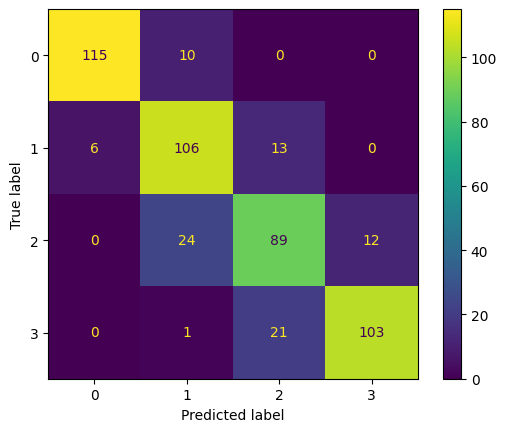

In [22]:
dts_model(X_all)

X_train Accuracy : 0.948
Depth : 27
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       375
           1       0.93      0.96      0.94       375
           2       0.93      0.91      0.92       375
           3       0.99      0.93      0.96       375

    accuracy                           0.95      1500
   macro avg       0.95      0.95      0.95      1500
weighted avg       0.95      0.95      0.95      1500

X_test Accuracy : 0.672
Depth : 27
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       125
           1       0.55      0.64      0.59       125
           2       0.58      0.48      0.53       125
           3       0.77      0.75      0.76       125

    accuracy                           0.67       500
   macro avg       0.67      0.67      0.67       500
weighted avg       0.67      0.67      0.67       500



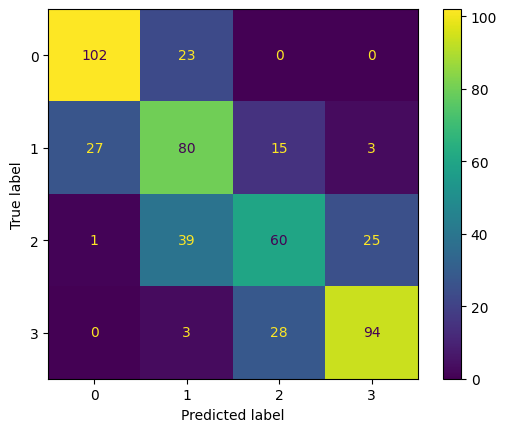

In [23]:
dts_model(X_only_ram)

X_train Accuracy : 1.0
Depth : 22
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       375
           1       1.00      1.00      1.00       375
           2       1.00      1.00      1.00       375
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

X_test Accuracy : 0.278
Depth : 22
              precision    recall  f1-score   support

           0       0.31      0.33      0.32       125
           1       0.25      0.26      0.26       125
           2       0.27      0.22      0.24       125
           3       0.28      0.30      0.29       125

    accuracy                           0.28       500
   macro avg       0.28      0.28      0.28       500
weighted avg       0.28      0.28      0.28       500



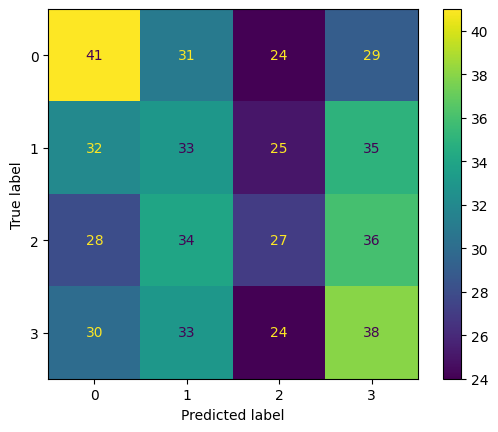

In [24]:
dts_model(X_no_ram)

X_train Accuracy : 1.0
Depth : 22
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       375
           1       1.00      1.00      1.00       375
           2       1.00      1.00      1.00       375
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

X_test Accuracy : 0.776
Depth : 22
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       125
           1       0.70      0.78      0.74       125
           2       0.70      0.59      0.64       125
           3       0.82      0.85      0.83       125

    accuracy                           0.78       500
   macro avg       0.78      0.78      0.77       500
weighted avg       0.78      0.78      0.77       500



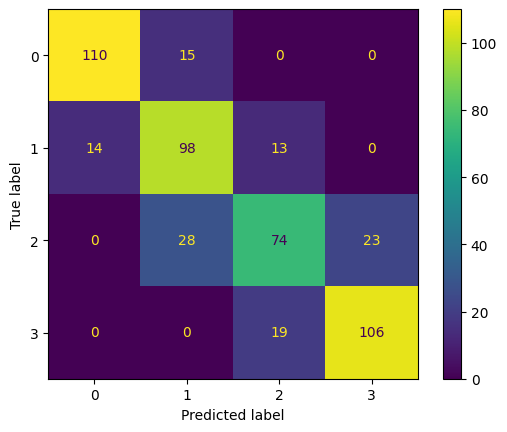

In [25]:
dts_model(X_r_b)

X_train Accuracy : 1.0
Depth : 11
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       375
           1       1.00      1.00      1.00       375
           2       1.00      1.00      1.00       375
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

X_test Accuracy : 0.82
Depth : 11
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       125
           1       0.77      0.82      0.80       125
           2       0.72      0.70      0.71       125
           3       0.85      0.84      0.85       125

    accuracy                           0.82       500
   macro avg       0.82      0.82      0.82       500
weighted avg       0.82      0.82      0.82       500



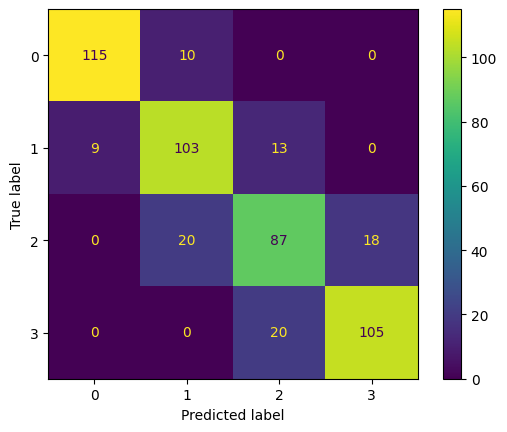

In [26]:
dts_model(X_reduce4)

>`Player 2` is the only model that avoids overfitting with default parameters.

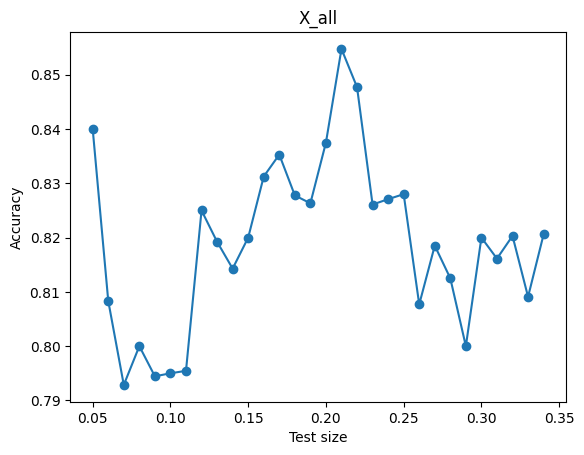

    Test size  Accuracy
16       0.21  0.854762
17       0.22  0.847727
0        0.05  0.840000


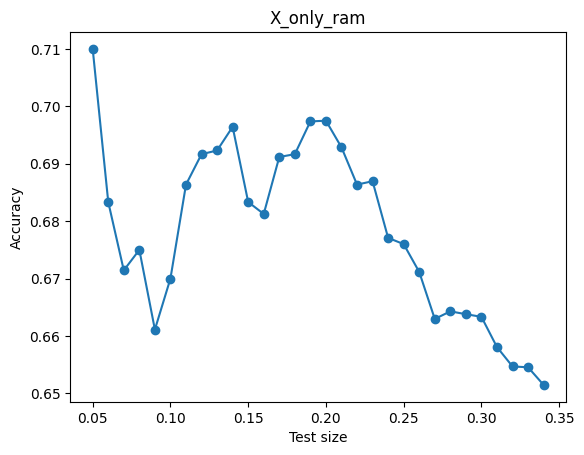

    Test size  Accuracy
0        0.05  0.710000
15       0.20  0.697500
14       0.19  0.697368


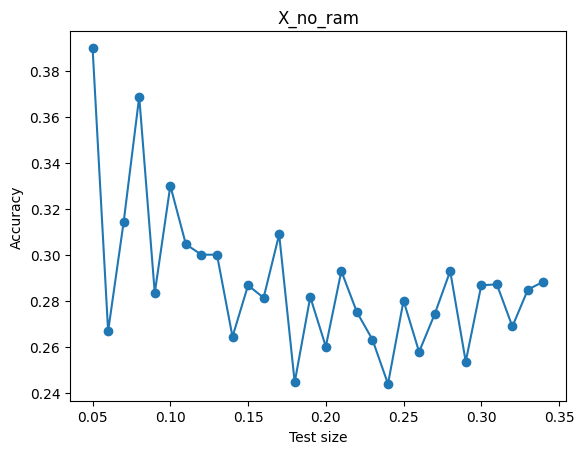

   Test size  Accuracy
0       0.05   0.39000
3       0.08   0.36875
5       0.10   0.33000


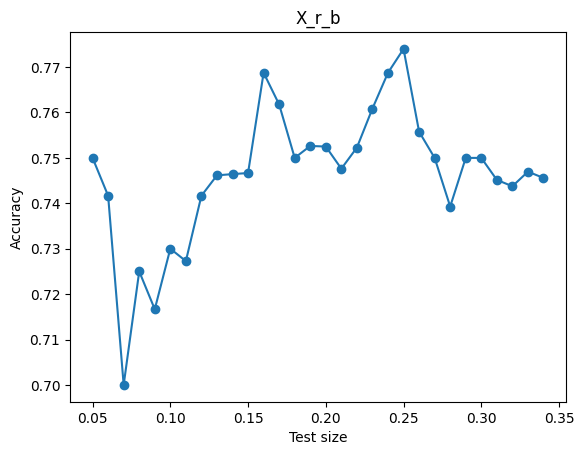

    Test size  Accuracy
20       0.25   0.77400
11       0.16   0.76875
19       0.24   0.76875


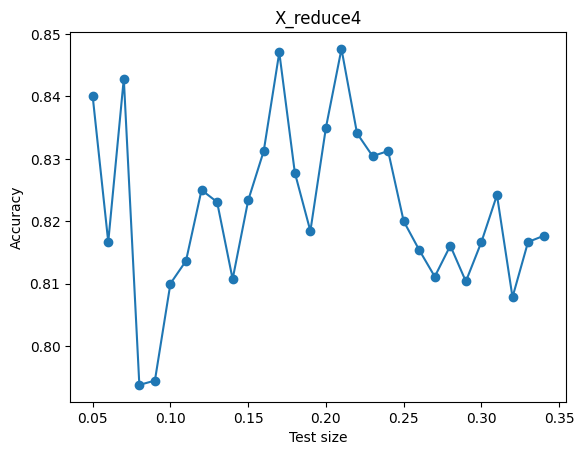

    Test size  Accuracy
16       0.21  0.847619
12       0.17  0.847059
2        0.07  0.842857


In [27]:
players = [X_all, X_only_ram, X_no_ram, X_r_b, X_reduce4]
players_name = ["X_all", "X_only_ram", "X_no_ram", "X_r_b", "X_reduce4"]
for i in range(len(players)):
    results = []
    for j in np.arange(.05, .35, .01):
        (X_train, X_test, y_train, y_test) = train_test_split(players[i],
                                                              y,
                                                              test_size = round(j, 2),
                                                              random_state = RANDOM_SEED,
                                                              stratify = y)
        
        Dts = DecisionTreeClassifier(random_state = RANDOM_SEED)
        Dts.fit(X_train, y_train)
    
        score = Dts.score(X_test, y_test)
        results.append({"Test size": j, "Accuracy": score})

    accuracy_score = pd.DataFrame(results)
    plt.scatter(accuracy_score["Test size"], accuracy_score["Accuracy"])
    plt.plot(accuracy_score["Test size"], accuracy_score["Accuracy"])
    plt.title(f"{players_name[i]}")
    plt.xlabel("Test size")
    plt.ylabel("Accuracy")
    plt.show()
    print(accuracy_score.nlargest(3, "Accuracy"))

>**Insights from the testing:**  
>1. While RAM is the primary factor, other features still exert a minor influence on the model's judgment.  
>2. X_all achieves the highest score; however, as previously noted, four of its columns contain irrational values and collinearity.
>  
>**Action Plan:**  
>1. To streamline redundant testing, I will proceed with `Player 5 : X_reduce4` for subsequent steps.  
>2. PCA (Principal Component Analysis) may be implemented for further evaluation.  
>I will re-verify the model to monitor for any signs of overfitting.
>
>I will re-verify the model to monitor for any signs of overfitting or underfitting.

In [28]:
results = []
for i in np.arange(.05, .35, .01):
    (X_train, X_test, y_train, y_test) = train_test_split(X_reduce4,
                                                          y,
                                                          test_size = round(i, 2),
                                                          random_state = RANDOM_SEED,
                                                          stratify = y)

    Dts = DecisionTreeClassifier(random_state = RANDOM_SEED)
    val_socres = cross_val_score(Dts, X_train, y_train, cv = 5)

    Dts.fit(X_train, y_train)

    results.append({"Test size": i,
                    "Train score mean": round(val_socres.mean(), 4),
                    "Train accuracy": round(Dts.score(X_train, y_train), 4),
                    "Stability": round(val_socres.std(), 4),
                    "Test accuracy": round(Dts.score(X_test, y_test), 4)})

accuracy_score = pd.DataFrame(results)
print(accuracy_score.nlargest(3, "Train score mean"))
print(accuracy_score.nlargest(3, "Train accuracy"))
print(accuracy_score.nsmallest(3, "Stability"))
print(accuracy_score.nlargest(3, "Test accuracy"))

   Test size  Train score mean  Train accuracy  Stability  Test accuracy
0       0.05            0.8358             1.0     0.0122         0.8400
2       0.07            0.8355             1.0     0.0162         0.8429
6       0.11            0.8354             1.0     0.0119         0.8136
   Test size  Train score mean  Train accuracy  Stability  Test accuracy
0       0.05            0.8358             1.0     0.0122         0.8400
1       0.06            0.8250             1.0     0.0107         0.8167
2       0.07            0.8355             1.0     0.0162         0.8429
    Test size  Train score mean  Train accuracy  Stability  Test accuracy
22       0.27            0.8295             1.0     0.0050         0.8111
12       0.17            0.8259             1.0     0.0064         0.8471
7        0.12            0.8227             1.0     0.0075         0.8250
    Test size  Train score mean  Train accuracy  Stability  Test accuracy
16       0.21            0.8241             1.

X_train Accuracy : 1.0
Depth : 11
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       415
           1       1.00      1.00      1.00       415
           2       1.00      1.00      1.00       415
           3       1.00      1.00      1.00       415

    accuracy                           1.00      1660
   macro avg       1.00      1.00      1.00      1660
weighted avg       1.00      1.00      1.00      1660

X_test Accuracy : 0.8470588235294118
Depth : 11
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        85
           1       0.83      0.85      0.84        85
           2       0.77      0.75      0.76        85
           3       0.86      0.86      0.86        85

    accuracy                           0.85       340
   macro avg       0.85      0.85      0.85       340
weighted avg       0.85      0.85      0.85       340



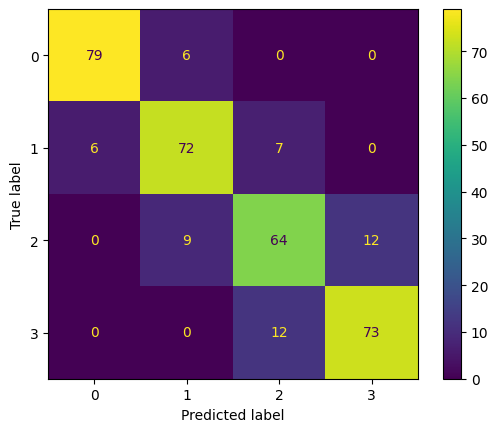

In [29]:
dts_model(X_reduce4, test_size = .17)

>Without limiting the depth of the DecisionTreeClassifier, overfitting is inevitable.  
>At a `test_size of 0.17`, the model achieves a stability (Std) of 0.0064, 
>performing very well in both `Train score mean` and `Test accuracy`.  
>Although it isn't the top performer in any single metric, **it offers the best overall balance.**

In [30]:
plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(), annot=True)
plt.show()
# print(df.info())
# print(df.describe())
# print(df.columns)
# print(df.shape)
std = StandardScaler()
data_y = df["price_range"]
data_X = std.fit_transform(df.loc[:, :"wifi"])

(X_train, X_test, y_train, y_test) = train_test_split(data_X, data_y, random_state = 0, stratify = data_y, test_size = 0.2)
# print(X_train.shape)
# print(X_test.shape)
# print(y_train.shape)
# print(y_test.shape)

# KN_model_fit = KNeighborsClassifier(n_neighbors = 4).fit(X_train, y_train)
# KN_model_y = KN_model_fit.predict(X_test)
# KN_model_proba = KN_model_fit.predict_proba(X_test)
# accuracy = KN_model_fit.score(X_test, y_test)
# print(f"Accuracy : {accuracy:.4f}")
# from sklearn.metrics import classification_report, confusion_matrix

# # 1. 直接看準確率
# score = KN_model_fit.score(X_test, y_test)
# print(f"整體準確率 (Accuracy): {score:.2%}")

# # 2. 查看每一類的詳細表現 (精準度、召回率)
# print("\n詳細分類報告：")
# print(classification_report(y_test, KN_model_y))

# # 3. 混淆矩陣 (看哪幾類容易被混淆)
# print("混淆矩陣：")
# print(confusion_matrix(y_test, KN_model_y))

NameError: name 'df' is not defined

<Figure size 2000x2000 with 0 Axes>